In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print(df.shape)

(8807, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

1. This dataset contains information about Netflix Movies and TV Shows.
2. It consists of 8807 records and 12 columns.
3. The dataset contains information about Netflix Movies and TV Shows. It consists of 8,807 records and 12 attributes. The data includes content details such as title, type, director, cast, country, release year, rating, duration, genres, and descriptions. Some attributes contain missing values that require preprocessing before analysis. This dataset is suitable for performing exploratory data analysis to identify content trends, popular genres, country-wise distribution, and Netflix growth patterns.
4. Some columns contain missing values, especially director, cast, country, and date_added.
5. The dataset can be used to analyze Netflix content trends, genres, countries, and release patterns.

In [ ]:
#DATA CLEANING

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['director'] = df['director'].fillna('Unknown')

In [ ]:
df['cast'] = df['cast'].fillna('Not Available')

In [ ]:
df['country'] = df['country'].fillna('Unknown')

In [ ]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
df['date_added'] = df['date_added'].fillna('Unknown')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# format of date
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

In [ ]:
df['date_added'].head(3)

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [ ]:
df = df.dropna(subset=['date_added'])

In [ ]:
df = df.dropna(subset=['duration'])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0




1. Missing values in director were replaced with "Unknown".
2. Missing cast values were replaced with "Not Available".
3. Missing country values were replaced with "Unknown".
4. Missing ratings were filled using the most frequent rating.
5. Duplicate records were removed.
6. date_added was converted into datetime format
for time-based analysis.
7. records contained missing values . Since the number was very small, these records were removed from the dataset.





In [ ]:
#EDA

In [ ]:
#  1. Are Movies more common than TV Shows on Netflix?

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2578


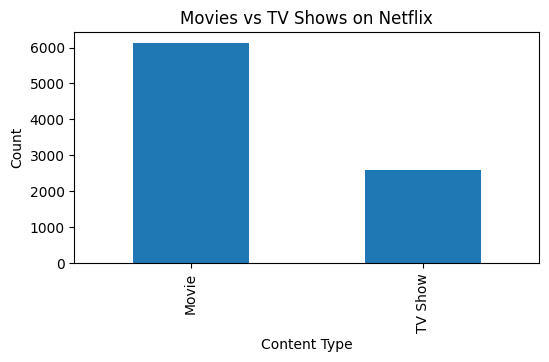

In [ ]:
#barchart
import matplotlib.pyplot as plt
type_count = df['type'].value_counts()
plt.figure(figsize=(6,3))
type_count.plot(kind='bar')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

Movies are significantly more common than TV Shows on Netflix. This indicates that Netflix has historically focused more on movie content than television series.

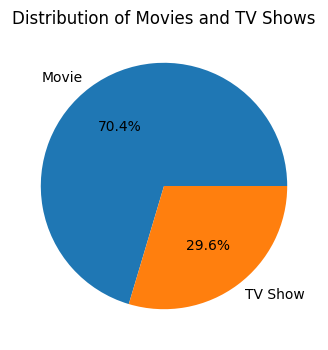

In [ ]:
# pie chart
plt.figure(figsize=(6,4))
df['type'].value_counts().plot( kind='pie',autopct='%1.1f%%')
plt.title('Distribution of Movies and TV Shows')
plt.ylabel('')
plt.show()

Movies contribute the majority share of Netflix content, while TV Shows account for a smaller proportion of the catalog.

 Q2. Which countries produce the most Netflix content?

In [ ]:
top_countries = df['country'].value_counts().head(10)
print(top_countries)

country
United States     2775
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64


In [ ]:
country_df = df[df['country'] != 'Unknown']
top_countries = country_df['country'].value_counts().head(10)

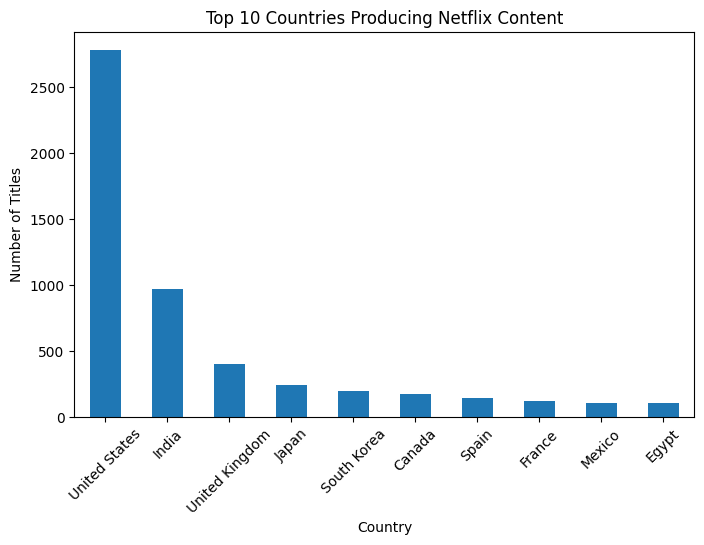

In [ ]:
plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

The United States contributes the highest amount of content on Netflix, followed by other major entertainment-producing countries.

Q3. Which year had the highest number of content releases?

In [ ]:
year_count = df['release_year'].value_counts().sort_index()
year_count.tail(20)

,count
release_year,
2002,51
2003,59
2004,64
2005,78
2006,96
2007,88
2008,135
2009,151
2010,189


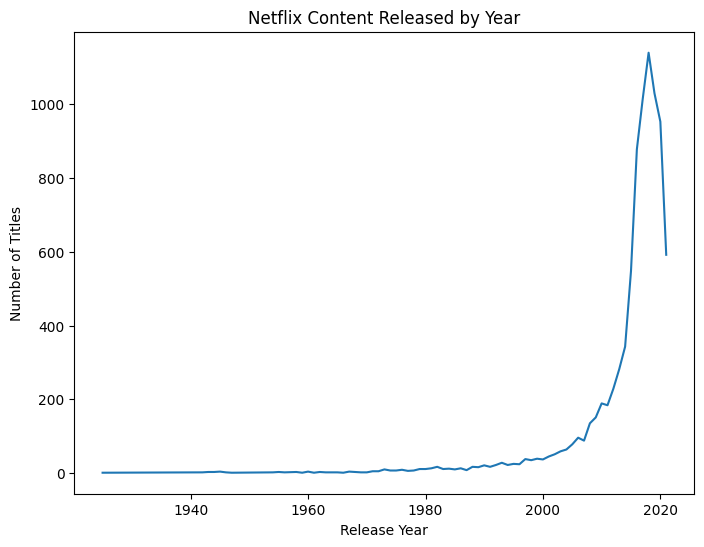

In [ ]:
#line chart
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
year_count.plot()
plt.title('Netflix Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

The number of titles released increased rapidly after 2000, showing significant growth in Netflix content availability.

Q4. What are the most common content ratings?

In [ ]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3187
TV-14,2133
TV-PG,838
R,799
PG-13,490
TV-Y7,330
TV-Y,300
PG,287
TV-G,212


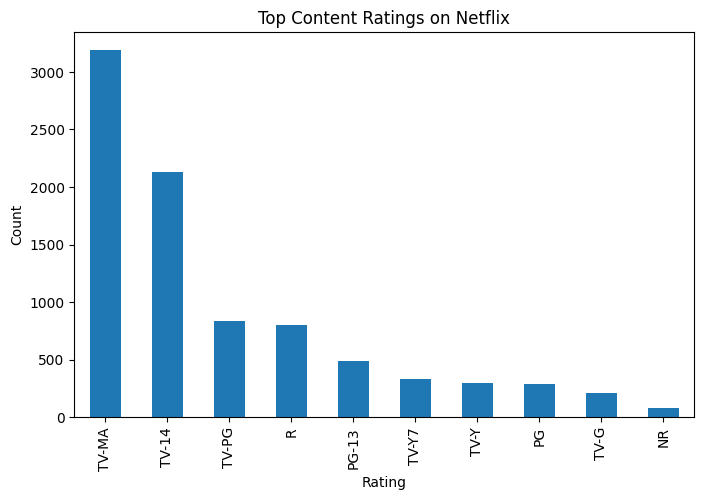

In [ ]:
plt.figure(figsize=(8,5))
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title('Top Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

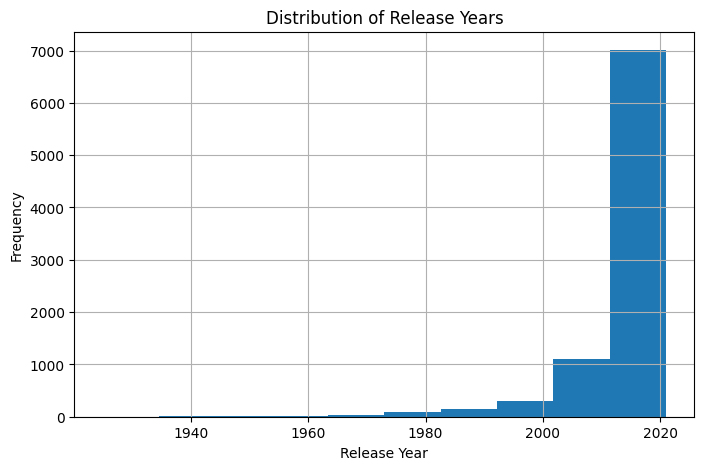

In [ ]:
# histogram
plt.figure(figsize=(8,5))
df['release_year'].hist()
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

Most Netflix content belongs to recent years, indicating a focus on modern productions.

Q5. What are the most popular genres on Netflix?

In [ ]:
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1328
Documentaries,869
Action & Adventure,859
Independent Movies,756
TV Dramas,739
Children & Family Movies,641


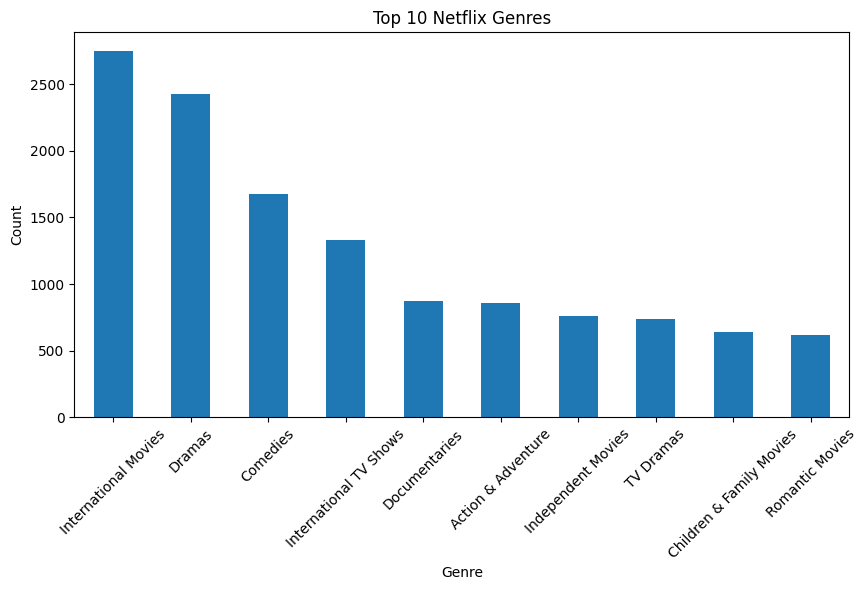

In [ ]:
#barchart
top_genres = genres.value_counts().head(10)
plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Drama, International Movies, and Comedy are among the most common genres on Netflix.

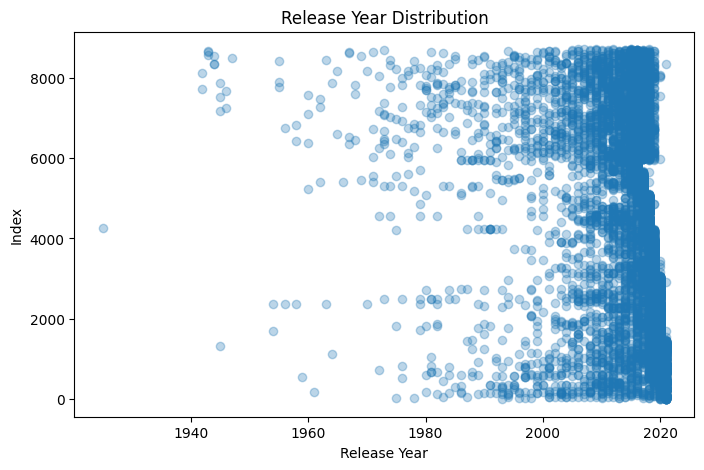

In [ ]:
#scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df['release_year'],range(len(df)),alpha=0.3)
plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Index')
plt.show()

The scatter plot shows that most Netflix content is concentrated in recent years, especially after 2010.

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df.head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


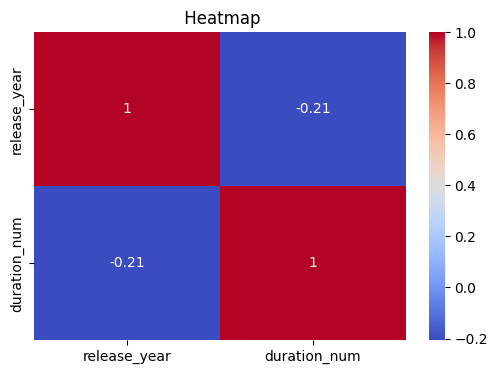

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = movie_df[['release_year','duration_num']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(' Heatmap')
plt.show()

The correlation between release year and movie duration is very weak. This indicates that the length of movies has remained relatively consistent over time and is not strongly influenced by the release year.

#Insights

 1:
Movies significantly outnumber TV Shows on Netflix.

 2:
The United States contributes the largest share of Netflix content.

 3:
Netflix content releases increased rapidly after the year 2000.

 4:
Recent productions dominate the Netflix catalog.

 5:
Drama and International content are among the most popular genres available on the platform.

# Surprising find

The most surprising finding was the dominance of movies over TV Shows in the Netflix catalog. Another interesting observation was the strong contribution of international content, showing Netflix’s global reach. The rapid increase in content after 2000 also highlights the platform’s expansion and growing demand for digital entertainment.